## scatter matrix / pair plot

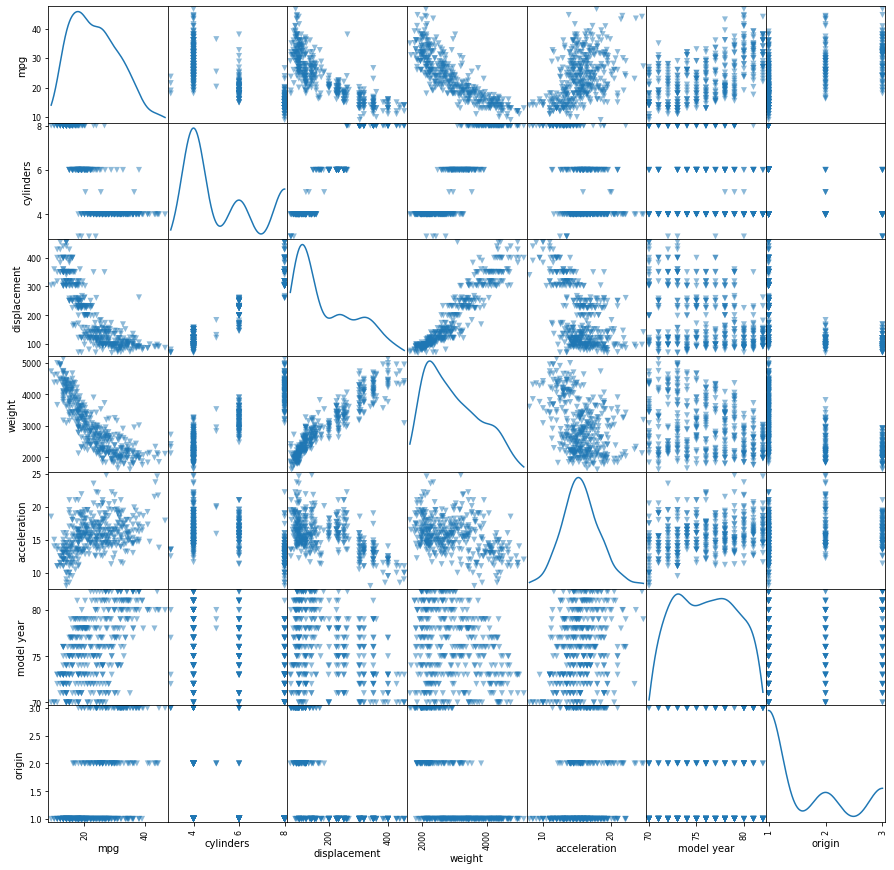

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv('auto-mpg.csv')
pd.plotting.scatter_matrix(df,figsize=[15,15],marker='v',alpha=0.5,diagonal="kde")   #Kernal density estimation
plt.show()

## parallel coordinates

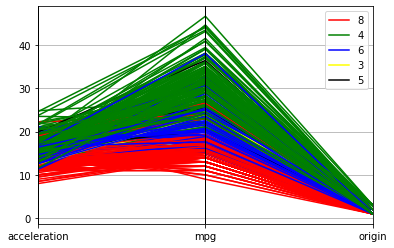

In [8]:
import pandas as pd
from pandas.plotting import parallel_coordinates
df=pd.read_csv('auto-mpg.csv')
pll=parallel_coordinates(df,'cylinders',cols=['acceleration','mpg','origin'],color=['red','green','blue','yellow','black'])

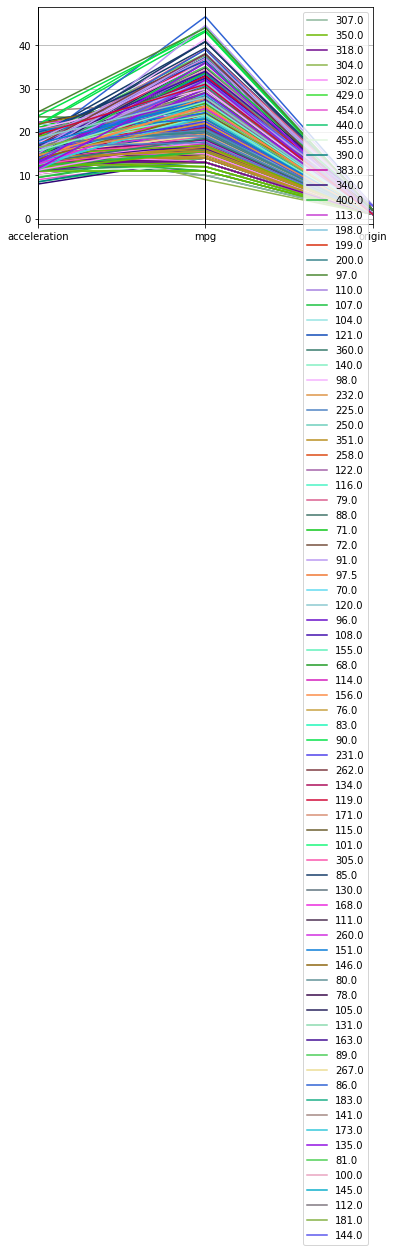

In [9]:
import pandas as pd
from pandas.plotting import parallel_coordinates
df=pd.read_csv('auto-mpg.csv')
pll=parallel_coordinates(df,'displacement',cols=['acceleration','mpg','origin'])

## cross tabulation

In [11]:
pd.crosstab(df['cylinders'],df['model year'],rownames=['cylinders'],colnames=['model year'],margins=True)

model year,70,71,72,73,74,75,76,77,78,79,80,81,82,All
cylinders,,,,,,,,,,,,,,
3,0,0,1,1,0,0,0,1,0,0,1,0,0,4
4,7,13,14,11,15,12,15,14,17,12,25,21,28,204
5,0,0,0,0,0,0,0,0,1,1,1,0,0,3
6,4,8,0,8,7,12,10,5,12,6,2,7,3,84
8,18,7,13,20,5,6,9,8,6,10,0,1,0,103
All,29,28,28,40,27,30,34,28,36,29,29,29,31,398


## data cleaning

#### missing Values

- 1) delete complete row with NaN. IT will delete the data of the row
- 2) fill with dummy data
- 3) fill with mean, median values

In [12]:
import pandas as pd
import numpy as np
sales_data=pd.DataFrame(
{'Name':['William','Emma','Sofia','markus','Edward','Thomas','Ethan',np.nan,'Arun','Ankita','Paul'],
'Region':[np.nan,'North','East',np.nan,'West','West','South',np.nan,'West','East','South'],
'Sales':[50000,52000,np.nan,np.nan,42000,72000,49000,np.nan,67000,65000,67000],
'expenses':[42000,43000,np.nan,np.nan,38000,39000,42000,np.nan,39000,50000,45000]})
sales_data

,Name,Region,Sales,expenses
0,William,NaN,50000.0,42000.0
1,Emma,North,52000.0,43000.0
2,Sofia,East,NaN,NaN
3,markus,NaN,NaN,NaN
4,Edward,West,42000.0,38000.0
5,Thomas,West,72000.0,39000.0
6,Ethan,South,49000.0,42000.0
7,NaN,NaN,NaN,NaN
8,Arun,West,67000.0,39000.0
9,Ankita,East,65000.0,50000.0


In [18]:
sales_data.isna().sum()

Name        1
Region      3
Sales       3
expenses    3
dtype: int64

In [17]:
# data cleaning method 1
sales_data.dropna(how="all") # using inplace=True you can update the original data

,Name,Region,Sales,expenses
0,William,NaN,50000.0,42000.0
1,Emma,North,52000.0,43000.0
2,Sofia,East,NaN,NaN
3,markus,NaN,NaN,NaN
4,Edward,West,42000.0,38000.0
5,Thomas,West,72000.0,39000.0
6,Ethan,South,49000.0,42000.0
8,Arun,West,67000.0,39000.0
9,Ankita,East,65000.0,50000.0
10,Paul,South,67000.0,45000.0


In [20]:
sales_data.dropna(thresh=2)

,Name,Region,Sales,expenses
0,William,NaN,50000.0,42000.0
1,Emma,North,52000.0,43000.0
2,Sofia,East,NaN,NaN
4,Edward,West,42000.0,38000.0
5,Thomas,West,72000.0,39000.0
6,Ethan,South,49000.0,42000.0
8,Arun,West,67000.0,39000.0
9,Ankita,East,65000.0,50000.0
10,Paul,South,67000.0,45000.0


In [21]:
sales_data.dropna(thresh=3)

,Name,Region,Sales,expenses
0,William,NaN,50000.0,42000.0
1,Emma,North,52000.0,43000.0
4,Edward,West,42000.0,38000.0
5,Thomas,West,72000.0,39000.0
6,Ethan,South,49000.0,42000.0
8,Arun,West,67000.0,39000.0
9,Ankita,East,65000.0,50000.0
10,Paul,South,67000.0,45000.0


In [23]:
sales_data.dropna(subset=['Sales','expenses'])

,Name,Region,Sales,expenses
0,William,NaN,50000.0,42000.0
1,Emma,North,52000.0,43000.0
4,Edward,West,42000.0,38000.0
5,Thomas,West,72000.0,39000.0
6,Ethan,South,49000.0,42000.0
8,Arun,West,67000.0,39000.0
9,Ankita,East,65000.0,50000.0
10,Paul,South,67000.0,45000.0


In [26]:
sales_data.dropna(axis=1)        #axis=1 deletes all data of that column if any vertical column has null value

""
0
1
2
3
4
5
6
7
8
9


In [27]:
# data cleaning method 2

sales_data.fillna(0)

,Name,Region,Sales,expenses
0,William,0,50000.0,42000.0
1,Emma,North,52000.0,43000.0
2,Sofia,East,0.0,0.0
3,markus,0,0.0,0.0
4,Edward,West,42000.0,38000.0
5,Thomas,West,72000.0,39000.0
6,Ethan,South,49000.0,42000.0
7,0,0,0.0,0.0
8,Arun,West,67000.0,39000.0
9,Ankita,East,65000.0,50000.0


In [29]:
sales_data['Name'].fillna('Extra')

0     William
1        Emma
2       Sofia
3      markus
4      Edward
5      Thomas
6       Ethan
7       Extra
8        Arun
9      Ankita
10       Paul
Name: Name, dtype: object

In [30]:
# data cleaning using method 3
sales_data['Sales'].fillna(sales_data['Sales'].mean())

0     50000.0
1     52000.0
2     58000.0
3     58000.0
4     42000.0
5     72000.0
6     49000.0
7     58000.0
8     67000.0
9     65000.0
10    67000.0
Name: Sales, dtype: float64

In [35]:
import numpy as np
df=pd.read_csv('auto-mpg2.csv')
df.loc[df['horsepower']=='?','horsepower']=np.nan
df['horsepower'].fillna(df['horsepower'].mean())

0      130.0
1      165.0
2      150.0
3      150.0
4      140.0
       ...  
393     86.0
394     52.0
395     84.0
396     79.0
397     82.0
Name: horsepower, Length: 398, dtype: float64

In [36]:
df.loc[df['horsepower']=='?']

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name


In [37]:
df.loc[df['horsepower'].isna()]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name


In [38]:
df.drop('car name',axis=1)
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,1,ford ranger


# outliers

- IQR - Inter Quartile Range
- IQR = Q3-Q1                where Q3 = 75% value & Q1=25% value 
- low_value=Q1-1.5*IQR
- high_value=Q3+1.5*IQR

In [43]:
def find_outliers(ds,col):
    q1=ds[col].quantile(0.25)
    q3=ds[col].quantile(0.75)
    IQR=q3-q1
    low_value=q1-1.5*IQR
    high_value=q3+1.5*IQR
    print("low: ",low_value,', high: ',high_value)
    ds=ds.loc[(ds[col]<low_value) | (ds[col]>high_value)]
    return ds

In [45]:
import pandas as pd
df=pd.read_csv('auto-mpg.csv')
find_outliers(df,'acceleration')

low:  8.8 , high:  22.2


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
7,14.0,8,440.0,215,4312,8.5,70,1,plymouth fury iii
9,15.0,8,390.0,190,3850,8.5,70,1,amc ambassador dpl
11,14.0,8,340.0,160,3609,8.0,70,1,plymouth 'cuda 340
59,23.0,4,97.0,54,2254,23.5,72,2,volkswagen type 3
299,27.2,4,141.0,71,3190,24.8,79,2,peugeot 504
326,43.4,4,90.0,48,2335,23.7,80,2,vw dasher (diesel)
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup


In [50]:
def remove_outliers(ds,col):
    q1=ds[col].quantile(0.25)
    q3=ds[col].quantile(0.75)
    IQR=q3-q1
    low_value=q1-1.5*IQR
    high_value=q3+1.5*IQR
    print("low: ",low_value,', high: ',high_value)
    ds=ds.loc[(ds[col]>=low_value) & (ds[col]<=high_value)]
    return ds

In [51]:
remove_outliers(df,'acceleration')

low:  8.8 , high:  22.2


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
392,27.0,4,151.0,90,2950,17.3,82,1,chevrolet camaro
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


# Drop and Remove duplicates

In [52]:
import pandas as pd
data={'A':['TeamA','TeamB','TeamB','TeamC','TeamA'],'B':[50,40,40,30,50],'C':[True,False,False,False,True]}
df=pd.DataFrame(data)
df

,A,B,C
0,TeamA,50,True
1,TeamB,40,False
2,TeamB,40,False
3,TeamC,30,False
4,TeamA,50,True


In [53]:
df.duplicated()

0    False
1    False
2     True
3    False
4     True
dtype: bool

In [55]:
df.duplicated(keep='first')

0    False
1    False
2     True
3    False
4     True
dtype: bool

In [56]:
df.duplicated(keep='last')

0     True
1     True
2    False
3    False
4    False
dtype: bool

In [57]:
df.duplicated(keep=False)

0     True
1     True
2     True
3    False
4     True
dtype: bool

In [60]:
df.drop_duplicates(keep='first') # do same for last and False

,A,B,C
0,TeamA,50,True
1,TeamB,40,False
3,TeamC,30,False


In [61]:
df.reset_index(drop=True)

,A,B,C
0,TeamA,50,True
1,TeamB,40,False
2,TeamB,40,False
3,TeamC,30,False
4,TeamA,50,True
